In [10]:
import numpy as np
import matplotlib.pyplot as plt
# 设置中文字体（以 Windows 系统为例，黑体/微软雅黑都支持）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 或者 ['SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号 '-' 显示为方块的问题

In [11]:
#import numpy as np
#from datetime import datetime
#print(datetime.now())
#print(datetime.now().timestamp())
#np.random.seed(int(datetime.now().timestamp()))
#print(np.random.rand())

## 模拟原始实验数据

In [12]:
# 真实函数(未知, 但此处用于演示) y = 0.5*x^2 + x + 2
def true_func(x):
    return 0.67 * x**2 + x + 3.5

In [13]:
np.random.seed(42)   # 设定随机产生的种子，保证可重复性 

# 训练数据：范围 [-3, 3] 内 20 个点，添加高斯噪声
x_train = np.linspace(-3, 3, 20)
y_true = true_func(x_train)
noise = np.random.normal(0, 0.5, size=x_train.shape)
y_train = y_true + noise

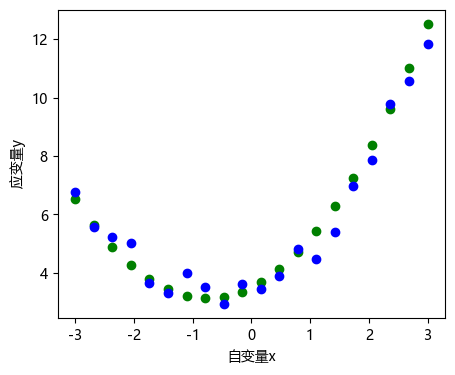

In [14]:
fig=plt.figure(figsize=(5,4))
plt.scatter(x_train,y_true,c="green")
plt.scatter(x_train,y_train,c="blue")
plt.xlabel("自变量x")
plt.ylabel("应变量y")
plt.savefig("模拟实验数据.png",dpi=400,transparent=True)

## 学习：使用内置函数

In [50]:
# ---- 2.1 拟合多项式系数 ----
coef = np.polyfit(x_train, y_train, deg=2)   # 最小二乘法
poly_func = np.poly1d(coef)                  # 生成多项式函数对象

In [16]:
poly_func

poly1d([0.66078126, 0.8423558 , 3.44491812])

In [17]:
x_plot = np.linspace(-3, 3, 500)
y_plot_pred = poly_func(x_plot)     # 稠密点上的预测值（用于画曲线）

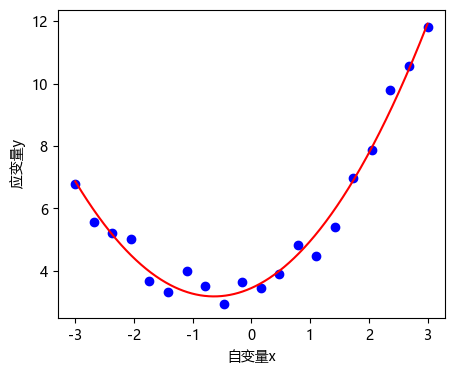

In [18]:
fig=plt.figure(figsize=(5,4))
plt.scatter(x_train,y_train,c="blue")
plt.plot(x_plot,y_plot_pred,c="red")
plt.xlabel("自变量x")
plt.ylabel("应变量y")
plt.savefig("模拟实验数据的拟合.png",dpi=400,transparent=True)

## 预测

In [19]:
x_test = np.linspace(3, 5, 5)
y_test_true = true_func(x_test)
noise_test = np.random.normal(0, 0.5, size=x_test.shape)
y_test = y_test_true + noise_test

In [20]:
x_plot = np.linspace(-3, 7, 500)
y_plot_pred = poly_func(x_plot)     # 稠密点上的预测值（用于画曲线）

In [21]:
x_ExpValid = np.linspace(5.5, 7, 4)
y_ExpValid = poly_func(x_ExpValid)

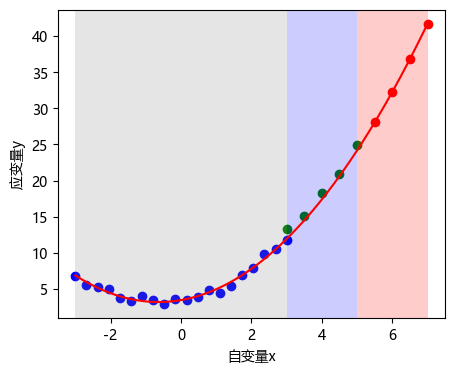

In [22]:
fig=plt.figure(figsize=(5,4))
plt.scatter(x_train,y_train,c="blue")
plt.scatter(x_test,y_test,c="green")
plt.plot(x_plot,y_plot_pred,c="red")
plt.scatter(x_ExpValid,y_ExpValid,c="red")
plt.xlabel("自变量x")
plt.ylabel("应变量y")
plt.axvspan(-3, 3, facecolor='grey', alpha=0.2)
plt.axvspan(3, 5, facecolor='blue', alpha=0.2)
plt.axvspan(5, 7, facecolor='red', alpha=0.2)
plt.savefig("模拟实验数据的预测.png",dpi=400,transparent=True)

## 欠拟合

In [23]:
# ---- 2.1 拟合多项式系数 ----
coef = np.polyfit(x_train, y_train, deg=1)   # 最小二乘法
poly_func_under = np.poly1d(coef)                  # 生成多项式函数对象

In [24]:
x_plot = np.linspace(-3, 5, 500)
y_plot_pred = poly_func_under(x_plot)     # 稠密点上的预测值（用于画曲线）

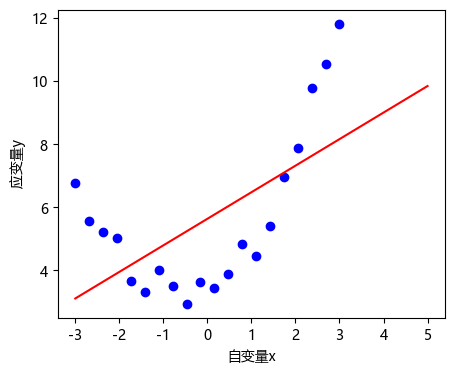

In [26]:
fig=plt.figure(figsize=(5,4))
plt.scatter(x_train,y_train,c="blue")
plt.plot(x_plot,y_plot_pred,c="red")
plt.xlabel("自变量x")
plt.ylabel("应变量y")
plt.savefig("模拟实验数据的欠拟合.png",dpi=400,transparent=True)

## 过拟合

In [46]:
# ---- 2.1 拟合多项式系数 ----
coef = np.polyfit(x_train, y_train, deg=12)   # 最小二乘法
poly_func_over = np.poly1d(coef)                  # 生成多项式函数对象

In [47]:
x_plot = np.linspace(-3, 5, 500)
y_plot_pred = poly_func_over(x_plot)     # 稠密点上的预测值（用于画曲线）

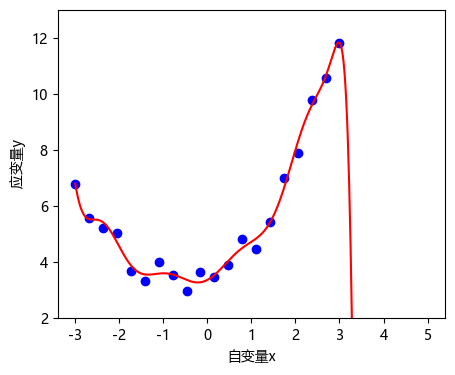

In [49]:
fig=plt.figure(figsize=(5,4))
plt.scatter(x_train,y_train,c="blue")
plt.plot(x_plot,y_plot_pred,c="red")
plt.xlabel("自变量x")
plt.ylabel("应变量y")
plt.ylim([2,13])
plt.savefig("模拟实验数据的过拟合.png",dpi=400,transparent=True)

## 损失函数

In [51]:
# ---- 2.1 拟合多项式系数 ----
coef = np.polyfit(x_train, y_train, deg=2)   # 最小二乘法
poly_func = np.poly1d(coef)                  # 生成多项式函数对象

In [53]:
coef

array([0.66078126, 0.8423558 , 3.44491812])

In [52]:
poly_func

poly1d([0.66078126, 0.8423558 , 3.44491812])

In [54]:
x_plot = np.linspace(-3, 3, 500)
y_plot_pred = poly_func(x_plot)     # 稠密点上的预测值（用于画曲线）

In [64]:
# 系数1
coef1 = np.array([0.6, 0.85 , 3.2])
poly_func1 = np.poly1d(coef1)  
y_plot_1 = poly_func1(x_plot)
# 系数2
coef2 = np.array([0.6, 1 , 3.2])
poly_func2 = np.poly1d(coef2)  
y_plot_2 = poly_func2(x_plot)
# 系数3
coef3 = np.array([0.8, 1 , 3.2])
poly_func3 = np.poly1d(coef3)  
y_plot_3 = poly_func3(x_plot)

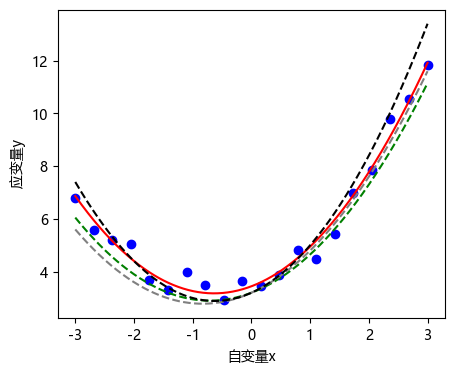

In [67]:
fig=plt.figure(figsize=(5,4))
plt.scatter(x_train,y_train,c="blue")
plt.plot(x_plot,y_plot_pred,c="red")
plt.plot(x_plot,y_plot_1,c="green",linestyle="--")
plt.plot(x_plot,y_plot_2,c="gray",linestyle="--")
plt.plot(x_plot,y_plot_3,c="black",linestyle="--")
plt.xlabel("自变量x")
plt.ylabel("应变量y")
plt.savefig("模拟实验数据的多条拟合.png",dpi=400,transparent=True)